# Sales Case Study — split, extract, filter, encode, end to end

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · **▶ 05 Feature Engineering** · 06 Regression · 07 Model Prep · 08 Case Studies

`05_Feature_Engineering/04_sales_case_study_full_pipeline.ipynb`

---

### In one paragraph (no jargon)

The three original sales notebooks merged into one continuous pipeline, because that's how the work actually happens: each stage consumes what the last one produced. Splitting a packed column, extracting date features, filtering rows, then encoding what's left. Read it top to bottom once and you have a template you can apply to any transactional dataset you're handed.

### After this notebook you can

- Split a column that holds two pieces of information into two clean columns
- Extract date-based features and compute elapsed time
- Filter and encode to produce a model-ready table
- Follow a multi-stage pipeline where each step depends on the last


### What's inside

1. Stage 1 — Feature splitting
2. Stage 2 — Feature extraction
3. Stage 3 — Filtering and encoding
4. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Feature** | One column used as an input to a model. |
| **Feature engineering** | Creating better columns from the ones you have — the step that usually improves a model more than changing the algorithm. |
| **Feature extraction** | Pulling a new column out of an existing one: month out of a date, title out of a name. |
| **Feature splitting** | Breaking one column into several: `"Yangon(Local)"` → city + type. |
| **Derived feature** | A column computed from others: profit = revenue − cost. |
| **Domain knowledge** | Knowing what the numbers mean in the business. This is what makes a good feature; no algorithm can supply it. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")
import tempfile
# WHY: the stages below save their output and the next stage reads it back,
#      exactly as the original separate notebooks did. Those intermediate files
#      go to a temporary folder so running this notebook leaves your notes clean.
EXPORT_DIR = tempfile.mkdtemp(prefix='bda_exports_')
print('Intermediate files for this notebook:', EXPORT_DIR)

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_sales():
    """Exact copy of sales.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Invoice ID,Branch,City(nature),Customer type,Gender,Product line,Unit price,Quantity,Profit,Total,Time,Payment,cogs,Total ,gross income,Rating,date_visited
750-67-8428,A,Yangon(Local),Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,13:08,Ewallet,522.83,4.761904762,26.1415,9.1,02-10-2016
226-31-3081,C,Naypyitaw(Local),Normal,Female,Electronic accessories,15.28,5.0,3.82,80.22,10:29,Cash,76.4,4.761904762,3.82,9.6,26-08-2018
&&&,A,Yangon(Local),Normal,Male,Home and lifestyle,46.33,6.0,16.2155,340.5255,13:23,Credit card,324.31,4.761904762,16.2155,7.4,14-09-2020
123-19-1176,A,Yangon(Local),Member,Male,Health and beauty,58.22,8.0,23.288,489.048,20:33,Ewallet,465.76,4.761904762,23.288,8.4,10-10-2022
373-73-7910,A,Yangon(Local),Normal,,Sports and travel,&&&,7.0,30.2085,634.3785,10:37,Ewallet,604.17,4.761904762,30.2085,5.3,28-09-2019
699-14-3026,C,Naypyitaw(Local),Normal,Male,Electronic accessories,85.39,7.0,29.8865,627.6165,18:30,Ewallet,597.73,4.761904762,29.8865,4.1,03-06-2019
355-53-5943,A,Yangon(Local),Member,Female,Electronic accessories,68.84,,20.652,433.692,14:36,Ewallet,413.04,4.761904762,20.652,5.8,05-06-2015
$$$,C,Naypyitaw(Local),Normal,Female,Home and lifestyle,73.56,10.0,36.78,772.38,11:38,Ewallet,735.6,4.761904762,36.78,8.0,17-03-2016
665-32-9167,A,Yangon(Local),Member,Female,Health and beauty,36.26,2.0,3.626,2356.23,17:15,Credit card,72.52,4.761904762,3.626,7.2,21-02-2018
692-92-5582,B,Mandalay(urban),Member,Female,Food and beverages,54.84,6.0,8.226,172.746,13:27,Credit card,164.52,4.761904762,,5.9,04-10-2012
351-62-0822,B,Mandalay(urban),Member,,Fashion accessories,13.25,4.0,2.896,60.816,18:07,Ewallet,57.92,4.761904762,2.896,4.5,29-01-2020
529-56-3974,B,Mandalay(urban),Member,Male,Electronic accessories,25.51,6.0,5.102,107.142,17:03,Cash,102.04,4.761904762,5.102,6.8,08-06-2019
365-64-0515,A,Naypyitaw(Local),Normal,Female,Electronic accessories,46.95,5.0,11.7375,246.4875,10:25,Ewallet,234.75,4.761904762,11.7375,7.1,21-05-2011
252-56-2699,A,Yangon(Local),Normal,Male,Food and beverages,21.25,10.0,21.595,453.495,16:48,Ewallet,431.9,4.761904762,21.595,8.2,12-10-2014
%%%,A,Yangon(Local),Normal,Female,Health and beauty,71.38,10.0,35.69,8975.36,19:21,Credit card,713.8,4.761904762,35.69,5.7,11-11-2016
299-46-1805,B,Mandalay(urban),Member,Female,Sports and travel,93.72,6.0,28.116,590.436,16:19,Cash,562.32,4.761904762,28.116,4.5,19-03-2014
656-95-9349,A,Yangon(Local),Member,Female,Health and beauty,68.93,,24.1255,506.6355,11:03,Credit card,482.51,4.761904762,24.1255,4.6,11-01-2018
***,A,Yangon(Local),Normal,Male,Sports and travel,72.61,6.0,21.783,457.443,10:39,Credit card,435.66,4.761904762,21.783,6.9,08-07-2015
329-62-1586,A,Yangon(Local),Normal,Male,Food and beverages,54.67,3.0,8.2005,172.2105,18:00,Credit card,164.01,4.761904762,8.2005,8.6,03-06-2014"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Intermediate files for this notebook: /tmp/bda_exports_nqsxehgg
Setup complete. pandas 3.0.2 | numpy 2.4.4


## Stage 1 — Feature splitting

The `City(nature)` column packs two facts into one string: the city and whether the customer is local. A column holding two things can't be analysed as either, so the first job is to split it. Same for the date column, which holds year, month and day.

# Feature Engineering — Sales Dataset (Step 1: Feature Split)

**Dataset:** `sales.csv` — 19 real supermarket transactions. This is genuinely messy, real-world-style data (not cleaned up for the demo): a few `Invoice ID` and `Unit price` cells contain junk placeholder tokens (`&&&`, `$$$`, `%%%`, `***`) instead of real values, `Quantity` has missing values, and there's even a duplicated `Total` column name (`'Total'` and `'Total '` with a trailing space). We clean all of this as part of the pipeline below, rather than hiding it.

This is **Step 1 of 3** in the Sales feature-engineering pipeline:
1. **Feature Split** (this notebook) — clean up messy raw fields and split compound columns into their components
2. `sales_feature_extraction.ipynb` — extract date-based features (year, month, day name, recency)
3. `sales_filter_label_encoding.ipynb` — encode categorical columns for modeling

Each step reads the previous step's saved output, exactly like a real preprocessing pipeline would.

## 1. Load & inspect the raw data — including its problems

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="flare")
plt.rcParams['figure.dpi'] = 100

df = load_data('sales.csv', rebuild=rebuild_sales)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 'sales.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (19, 17)
Columns: ['Invoice ID', 'Branch', 'City(nature)', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Profit', 'Total', 'Time', 'Payment', 'cogs', 'Total ', 'gross income', 'Rating', 'date_visited']


,Invoice ID,Branch,City(nature),Customer type,Gender,Product line,Unit price,Quantity,Profit,Total,Time,Payment,cogs,Total,gross income,Rating,date_visited
0,750-67-8428,A,Yangon(Local),Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1,02-10-2016
1,226-31-3081,C,Naypyitaw(Local),Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6,26-08-2018
2,&&&,A,Yangon(Local),Normal,Male,Home and lifestyle,46.33,6.0,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4,14-09-2020
3,123-19-1176,A,Yangon(Local),Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4,10-10-2022
4,373-73-7910,A,Yangon(Local),Normal,NaN,Sports and travel,&&&,7.0,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3,28-09-2019


In [3]:
# Duplicate-looking column names ('Total' and 'Total ' -- note the trailing space)
# are a classic silent bug: they LOOK the same to a human skimming the data,
# but pandas treats them as two entirely different columns.
duplicate_like = [c for c in df.columns if c.strip() in [x.strip() for x in df.columns if x != c]]
print("Columns that collide once whitespace is stripped:", duplicate_like)

# Fix: strip whitespace from every column name, then check for TRUE duplicates
df.columns = df.columns.str.strip()
print(f"\nAfter stripping column-name whitespace: {df.columns.tolist()}")
print(f"Any exact duplicate column names remain? {df.columns.duplicated().any()}")

Columns that collide once whitespace is stripped: ['Total', 'Total ']

After stripping column-name whitespace: ['Invoice ID', 'Branch', 'City(nature)', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Profit', 'Total', 'Time', 'Payment', 'cogs', 'Total', 'gross income', 'Rating', 'date_visited']
Any exact duplicate column names remain? True


In [4]:
# Junk placeholder tokens hiding inside otherwise-numeric/ID columns
print("Unique 'junk-looking' Invoice ID values (non-standard format):")
print(df.loc[~df['Invoice ID'].str.match(r'^\d{3}-\d{2}-\d{4}$'), 'Invoice ID'].tolist())

print("\n'Unit price' values that aren't valid numbers:")
non_numeric_price = df[pd.to_numeric(df['Unit price'], errors='coerce').isnull()]['Unit price']
print(non_numeric_price.tolist())

print(f"\nMissing Quantity values: {df['Quantity'].isnull().sum()}")

Unique 'junk-looking' Invoice ID values (non-standard format):
['&&&', '$$$', '%%%', '***']

'Unit price' values that aren't valid numbers:
['&&&']

Missing Quantity values: 2


## 2. Clean the junk before doing anything else
We convert unparseable placeholder tokens to proper missing values (`NaN`) so they're handled explicitly by the imputation techniques covered in `03_Data_Cleaning/`, rather than silently breaking downstream calculations.

In [5]:
df['Unit price'] = pd.to_numeric(df['Unit price'], errors='coerce')  # junk tokens -> NaN
df.loc[~df['Invoice ID'].str.match(r'^\d{3}-\d{2}-\d{4}$'), 'Invoice ID'] = np.nan

print(f"'Unit price' missing after cleaning: {df['Unit price'].isnull().sum()}")
print(f"'Invoice ID' missing after cleaning: {df['Invoice ID'].isnull().sum()}")

# For this small teaching dataset, median-impute Unit price and Quantity so the
# rest of the pipeline has a complete numeric matrix to work with
df['Unit price'] = df['Unit price'].fillna(df['Unit price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Invoice ID'] = df['Invoice ID'].fillna('UNKNOWN')
print("\nCleaned columns -- no more NaNs in Unit price / Quantity:")
df[['Invoice ID', 'Unit price', 'Quantity']].head()

'Unit price' missing after cleaning: 1
'Invoice ID' missing after cleaning: 4

Cleaned columns -- no more NaNs in Unit price / Quantity:


,Invoice ID,Unit price,Quantity
0,750-67-8428,74.69,7.0
1,226-31-3081,15.28,5.0
2,UNKNOWN,46.33,6.0
3,123-19-1176,58.22,8.0
4,373-73-7910,56.53,7.0


## 3. Splitting a compound column: `City(nature)` -> `City` + `City_Type`
`City(nature)` packs two distinct pieces of information into one string, e.g. `"Yangon(Local)"`. A regular expression pulls them apart into their own, independently-usable columns.

In [6]:
# Pattern: capture everything before the parenthesis as the city name,
# and the word INSIDE the parenthesis as the city's classification.
df[['City', 'City_Type']] = df['City(nature)'].str.extract(r'([A-Za-z\s]+)\((\w+)\)')
df[['City(nature)', 'City', 'City_Type']].head()

,City(nature),City,City_Type
0,Yangon(Local),Yangon,Local
1,Naypyitaw(Local),Naypyitaw,Local
2,Yangon(Local),Yangon,Local
3,Yangon(Local),Yangon,Local
4,Yangon(Local),Yangon,Local


## 4. Splitting the date column into its component parts

In [7]:
df['date_visited'] = pd.to_datetime(df['date_visited'], format='%d-%m-%Y', errors='coerce')
df['visit_day'] = df['date_visited'].dt.day
df['visit_month'] = df['date_visited'].dt.month
df['visit_year'] = df['date_visited'].dt.year

df[['date_visited', 'visit_day', 'visit_month', 'visit_year']].head()

,date_visited,visit_day,visit_month,visit_year
0,2016-10-02,2,10,2016
1,2018-08-26,26,8,2018
2,2020-09-14,14,9,2020
3,2022-10-10,10,10,2022
4,2019-09-28,28,9,2019


## 5. Quick visual check of the split results

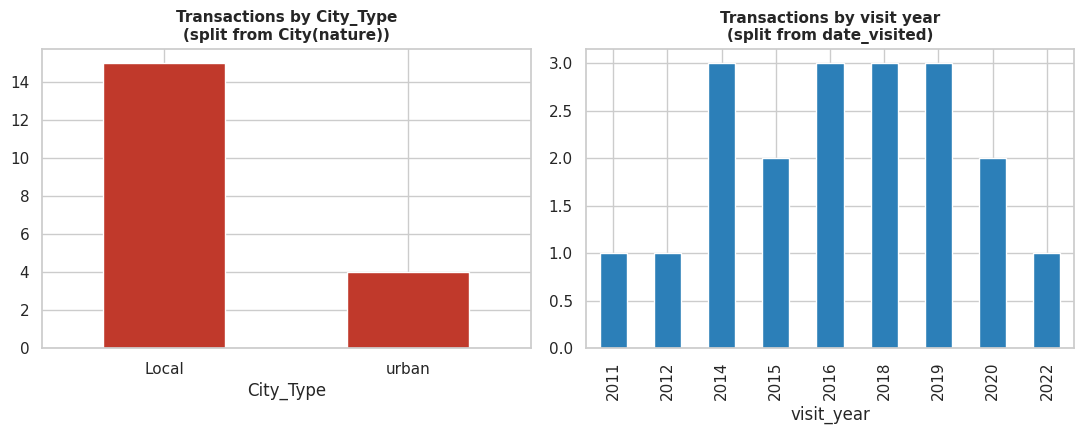

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df['City_Type'].value_counts().plot(kind='bar', ax=axes[0], color='#c0392b')
axes[0].set_title("Transactions by City_Type\n(split from City(nature))", fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

df['visit_year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#2c7fb8')
axes[1].set_title("Transactions by visit year\n(split from date_visited)", fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Save the cleaned, split output for the next pipeline step

In [9]:
df.to_csv(os.path.join(EXPORT_DIR, 'sales_feature_split.csv'), index=False)
print(f"Saved sales_feature_split.csv -- {df.shape[0]} rows, {df.shape[1]} columns")
print("Continue to sales_feature_extraction.ipynb, which loads this exact file.")

Saved sales_feature_split.csv -- 19 rows, 22 columns
Continue to sales_feature_extraction.ipynb, which loads this exact file.


## Stage 2 — Feature extraction

Now pull genuinely new information out of what we have: elapsed time since the visit, the day of the week, derived profit measures. This is where domain knowledge turns raw fields into something predictive.

# Feature Engineering — Sales Dataset (Step 2: Feature Extraction)

**Input:** `sales_feature_split.csv` (produced by `sales_feature_split.ipynb` — Step 1). This is **Step 2 of 3** in the pipeline: we now *derive new features* from the date column, rather than just splitting existing ones apart.

## 1. Load the Step-1 output

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

sns.set_theme(style="whitegrid", palette="flare")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(os.path.join(EXPORT_DIR, 'sales_feature_split.csv'))
df['date_visited'] = pd.to_datetime(df['date_visited'], errors='coerce')  # re-parse; CSV round-trips dates as strings
print(f"Shape: {df.shape}")
df[['date_visited', 'City', 'City_Type']].head()

Shape: (19, 22)


,date_visited,City,City_Type
0,2016-10-02,Yangon,Local
1,2018-08-26,Naypyitaw,Local
2,2020-09-14,Yangon,Local
3,2022-10-10,Yangon,Local
4,2019-09-28,Yangon,Local


## 2. Extracting calendar features
Beyond the day/month/year already split out in Step 1, `.dt` gives us richer calendar context: the day-of-week **name**, which can reveal patterns a raw date can't (e.g. "do customers spend more on weekends?").

In [11]:
df['year'] = df['date_visited'].dt.year
df['month'] = df['date_visited'].dt.month
df['day_name'] = df['date_visited'].dt.day_name()
df['is_weekend'] = df['date_visited'].dt.dayofweek.isin([5, 6])  # Saturday=5, Sunday=6

df[['date_visited', 'year', 'month', 'day_name', 'is_weekend']].head()

,date_visited,year,month,day_name,is_weekend
0,2016-10-02,2016,10,Sunday,True
1,2018-08-26,2018,8,Sunday,True
2,2020-09-14,2020,9,Monday,False
3,2022-10-10,2022,10,Monday,False
4,2019-09-28,2019,9,Saturday,True


## 3. Extracting "recency" features
`passed_years`/`passed_months` measure how long ago each visit happened, relative to *today*. This kind of feature is extremely common in churn/recency-based modeling (RFM analysis: Recency, Frequency, Monetary value).

In [12]:
today = date.today()
df['passed_years'] = today.year - df['date_visited'].dt.year
df['passed_months'] = (today.year - df['date_visited'].dt.year) * 12 + (today.month - df['date_visited'].dt.month)

df[['date_visited', 'passed_years', 'passed_months']].head()

,date_visited,passed_years,passed_months
0,2016-10-02,10,118
1,2018-08-26,8,96
2,2020-09-14,6,71
3,2022-10-10,4,46
4,2019-09-28,7,83


## 4. Visualizing the extracted features

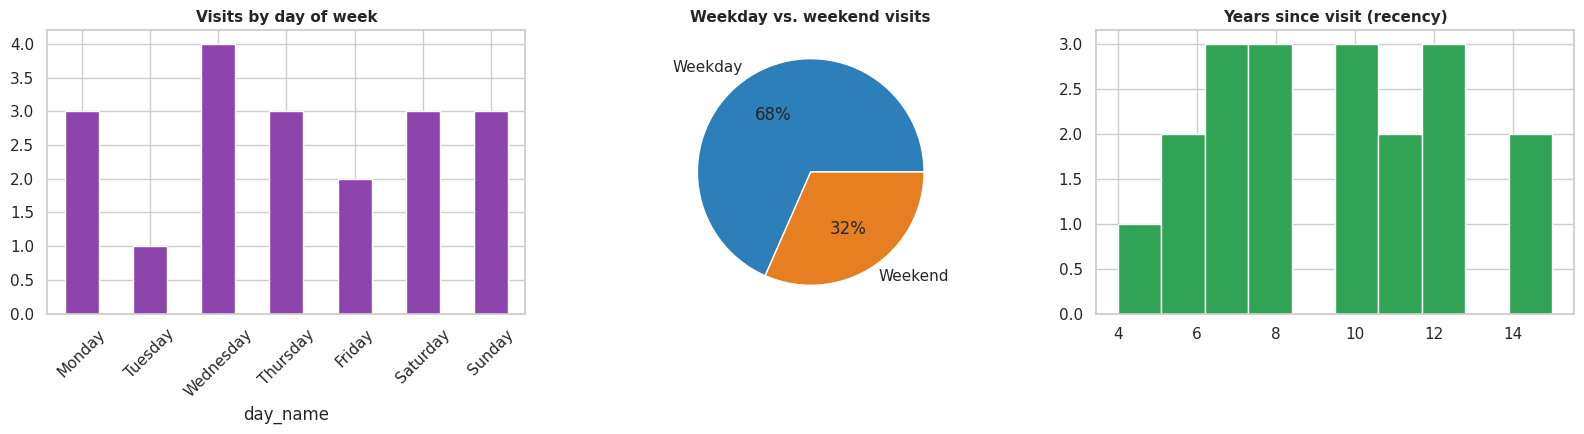

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['day_name'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', ax=axes[0], color='#8e44ad')
axes[0].set_title('Visits by day of week', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

df['is_weekend'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.0f%%',
                                      labels=['Weekday', 'Weekend'], colors=['#2c7fb8', '#e67e22'])
axes[1].set_title('Weekday vs. weekend visits', fontweight='bold', fontsize=11)
axes[1].set_ylabel('')

axes[2].hist(df['passed_years'], bins=10, color='#31a354', edgecolor='white')
axes[2].set_title('Years since visit (recency)', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Save for the next pipeline step

In [14]:
df.to_csv(os.path.join(EXPORT_DIR, 'sales_feature_extraction.csv'), index=False)
print(f"Saved sales_feature_extraction.csv -- {df.shape[0]} rows, {df.shape[1]} columns")
print("Continue to sales_filter_label_encoding.ipynb, which loads this exact file.")

Saved sales_feature_extraction.csv -- 19 rows, 28 columns
Continue to sales_filter_label_encoding.ipynb, which loads this exact file.


## Stage 3 — Filtering and encoding

Finally, filter to the rows we want and convert the remaining text columns to numbers so the data is model-ready.

# Feature Engineering — Sales Dataset (Step 3: Filtering & Categorical Encoding)

**Input:** `sales_feature_extraction.csv` (produced by Step 2). This is **Step 3 of 3**, the final step: filter out rows that are unusable for modeling, then encode every categorical column into a numeric form.

*(See `04_Data_Transformation/Categorical_Encoding/Categorical_Encoding_Techniques.ipynb` for a full catalog of encoding options — this notebook focuses on applying label encoding specifically, within this dataset's actual pipeline.)*

## 1. Load Step 2's output & filter unusable rows

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", palette="flare")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(os.path.join(EXPORT_DIR, 'sales_feature_extraction.csv'))
print(f"Shape before filtering: {df.shape}")

# Drop rows missing any of the columns we're about to encode -- a label encoder
# can't meaningfully assign a code to a missing value.
before = len(df)
df = df.dropna(subset=['Gender', 'Customer type', 'Payment']).reset_index(drop=True)
print(f"Shape after dropping rows with missing Gender/Customer type/Payment: {df.shape} "
      f"({before - len(df)} rows removed)")

Shape before filtering: (19, 28)
Shape after dropping rows with missing Gender/Customer type/Payment: (17, 28) (2 rows removed)


## 2. Label-encode the categorical columns
Each column gets its **own** `LabelEncoder` instance — reusing a single encoder across columns with different category sets would produce meaningless, cross-contaminated codes.

In [16]:
le_gender = LabelEncoder()
le_customer = LabelEncoder()
le_payment = LabelEncoder()

df['Gender_encoded'] = le_gender.fit_transform(df['Gender'])
df['Customer_encoded'] = le_customer.fit_transform(df['Customer type'])
df['Payment_encoded'] = le_payment.fit_transform(df['Payment'])

print("Learned mappings:")
print(f"  Gender:        {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"  Customer type: {dict(zip(le_customer.classes_, le_customer.transform(le_customer.classes_)))}")
print(f"  Payment:       {dict(zip(le_payment.classes_, le_payment.transform(le_payment.classes_)))}")

df[['Gender', 'Gender_encoded', 'Customer type', 'Customer_encoded', 'Payment', 'Payment_encoded']].head()

Learned mappings:
  Gender:        {'Female': np.int64(0), 'Male': np.int64(1)}
  Customer type: {'Member': np.int64(0), 'Normal': np.int64(1)}
  Payment:       {'Cash': np.int64(0), 'Credit card': np.int64(1), 'Ewallet': np.int64(2)}


,Gender,Gender_encoded,Customer type,Customer_encoded,Payment,Payment_encoded
0,Female,0,Member,0,Ewallet,2
1,Female,0,Normal,1,Cash,0
2,Male,1,Normal,1,Credit card,1
3,Male,1,Member,0,Ewallet,2
4,Male,1,Normal,1,Ewallet,2


## 3. Visualize the encoding results

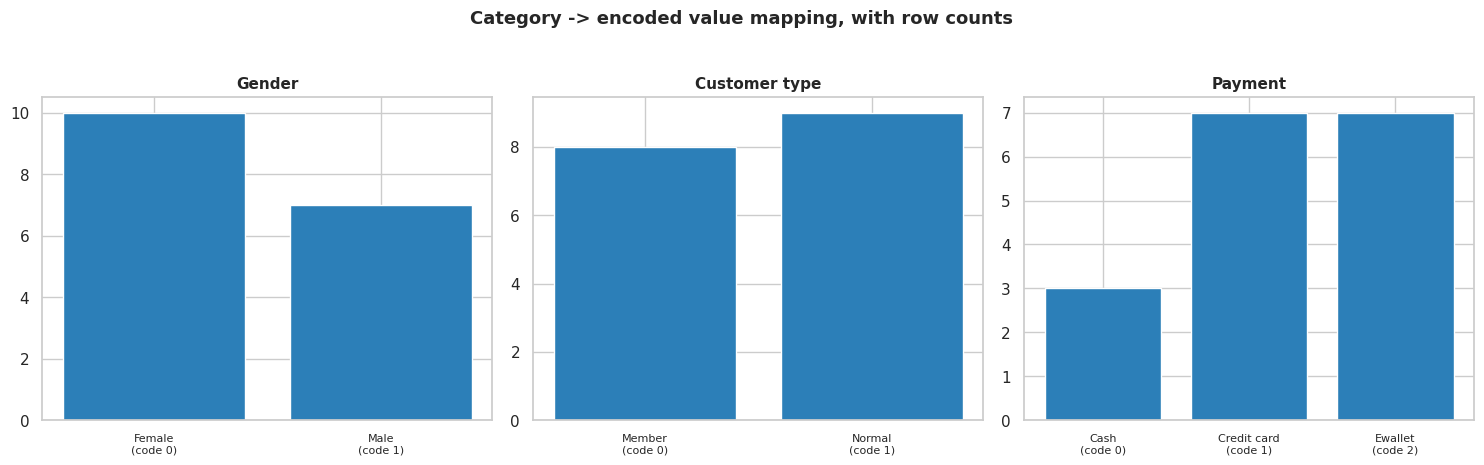

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, enc_col) in zip(axes, [('Gender', 'Gender_encoded'),
                                       ('Customer type', 'Customer_encoded'),
                                       ('Payment', 'Payment_encoded')]):
    counts = df.groupby([col, enc_col]).size().reset_index(name='count')
    ax.bar(counts[col].astype(str) + '\n(code ' + counts[enc_col].astype(str) + ')',
           counts['count'], color='#2c7fb8')
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=0, labelsize=8)
plt.suptitle('Category -> encoded value mapping, with row counts', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 4. Save the final, modeling-ready dataset

In [18]:
df.to_csv(os.path.join(EXPORT_DIR, 'sales_label_encoded.csv'), index=False)
print(f"Saved sales_label_encoded.csv -- {df.shape[0]} rows, {df.shape[1]} columns")
print("\nThis completes the Sales feature-engineering pipeline:")
print("  sales.csv -> sales_feature_split.csv -> sales_feature_extraction.csv -> sales_label_encoded.csv")

Saved sales_label_encoded.csv -- 17 rows, 31 columns

This completes the Sales feature-engineering pipeline:
  sales.csv -> sales_feature_split.csv -> sales_feature_extraction.csv -> sales_label_encoded.csv


---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Split a packed column | `s.str.split('(', expand=True)` |
| Strip leftover characters | `s.str.replace(')', '', regex=False)` |
| Text → date | `pd.to_datetime(s, format='%d-%m-%Y')` |
| Date parts | `s.dt.year` · `.dt.month` · `.dt.day_name()` |
| Elapsed time | `(pd.Timestamp.now() - s).dt.days` |
| Filter rows | `df[df['col'] == value]` |
| Label encode | `LabelEncoder().fit_transform(s)` |
| Save a stage | `df.to_csv('stage1.csv', index=False)` |

### Adapting this in the exam

- Given a column like `'Yangon(Local)'`? That's a splitting question — `str.split` with `expand=True`.
- 'Make the data model-ready' means: split what's packed, extract what's implicit, filter what's invalid, encode what's text.
- Save intermediate stages in a long pipeline so you can restart from the middle instead of the top.

### Traps that cost marks

- `str.split(..., expand=True)` returns a DataFrame. Without `expand=True` you get a column of lists, which nothing downstream can use.
- Splitting on `'('` leaves a trailing `')'` on the second part. Strip it.
- Indian-format dates (`02-10-2016` = 2 October) are misread as 10 February unless you pass `format='%d-%m-%Y'`.
- Each stage reads what the previous stage wrote — run the cells in order or you'll get a `FileNotFoundError`.
- Encoding before filtering wastes work and can create columns for categories you then remove.